# Regrecion multiple con dataset de sklearn

## Añadir datos

In [1]:
import pandas as pd
import numpy as np

data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
X_data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
y_target = raw_df.values[1::2, 2]

In [2]:
X_data = pd.DataFrame(X_data)

In [3]:
X_data

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0.0,0.573,6.593,69.1,2.4786,1.0,273.0,21.0,391.99,9.67
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,273.0,21.0,396.90,9.08
503,0.06076,0.0,11.93,0.0,0.573,6.976,91.0,2.1675,1.0,273.0,21.0,396.90,5.64
504,0.10959,0.0,11.93,0.0,0.573,6.794,89.3,2.3889,1.0,273.0,21.0,393.45,6.48


In [4]:
X_data=X_data.rename(columns={
    0 : "Crimen" ,
    1 : "Casas",
    2 : "Negocios",
    3 : "cerca de rio",
    4 : "contaminacion",
    5 : "cuartos",
    6 : "habitado",
    7 : "distancia centro",
    8 : "cercania autopista",
    9 : "impuestos",
    10 : "educacion",
    11 : "Negros",
    12 : "estatus" 
})

In [5]:
X_data.head()

,Crimen,Casas,Negocios,cerca de rio,contaminacion,cuartos,habitado,distancia centro,cercania autopista,impuestos,educacion,Negros,estatus
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33


In [6]:
y_target = pd.DataFrame(y_target)
y_target=y_target.rename(columns={
    0 : "Valor"})

In [7]:
y_target[0:6]

,Valor
0,24.0
1,21.6
2,34.7
3,33.4
4,36.2
5,28.7


## Crear datos de entrenamiento y prueba

In [8]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.stats.api as sms

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
X,X_test ,y,y_test = train_test_split(
                        X_data,y_target,random_state=1)

In [11]:
df = pd.concat( [X,y] ,axis =1 )

In [12]:
X.shape

(379, 13)

### Valores perdidos (Nill values)

In [13]:
X.isna().sum()

Crimen                0
Casas                 0
Negocios              0
cerca de rio          0
contaminacion         0
cuartos               0
habitado              0
distancia centro      0
cercania autopista    0
impuestos             0
educacion             0
Negros                0
estatus               0
dtype: int64

In [14]:
y.isna().sum()

Valor    0
dtype: int64

In [15]:
X.describe()

,Crimen,Casas,Negocios,cerca de rio,contaminacion,cuartos,habitado,distancia centro,cercania autopista,impuestos,educacion,Negros,estatus
count,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000,379.000000
mean,3.805183,11.521108,11.220053,0.081794,0.554073,6.255726,68.751451,3.824433,9.525066,405.182058,18.478100,358.304802,12.936174
std,9.375846,23.492644,6.875362,0.274413,0.117825,0.687415,28.276504,2.138449,8.734550,169.483657,2.141433,89.601791,7.243381
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,6.000000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000
25%,0.083475,0.000000,5.255000,0.000000,0.447500,5.875000,45.050000,2.094450,4.000000,277.000000,17.400000,376.125000,7.165000
50%,0.245220,0.000000,9.690000,0.000000,0.538000,6.172000,79.200000,3.317500,5.000000,329.000000,19.100000,392.040000,11.970000
75%,3.683390,17.750000,18.100000,0.000000,0.624000,6.611000,94.050000,5.108550,24.000000,666.000000,20.200000,396.220000,17.135000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000


In [16]:
y.describe()

,Valor
count,379.000000
mean,22.344591
std,8.920931
min,5.000000
25%,17.100000
50%,20.800000
75%,25.000000
max,50.000000


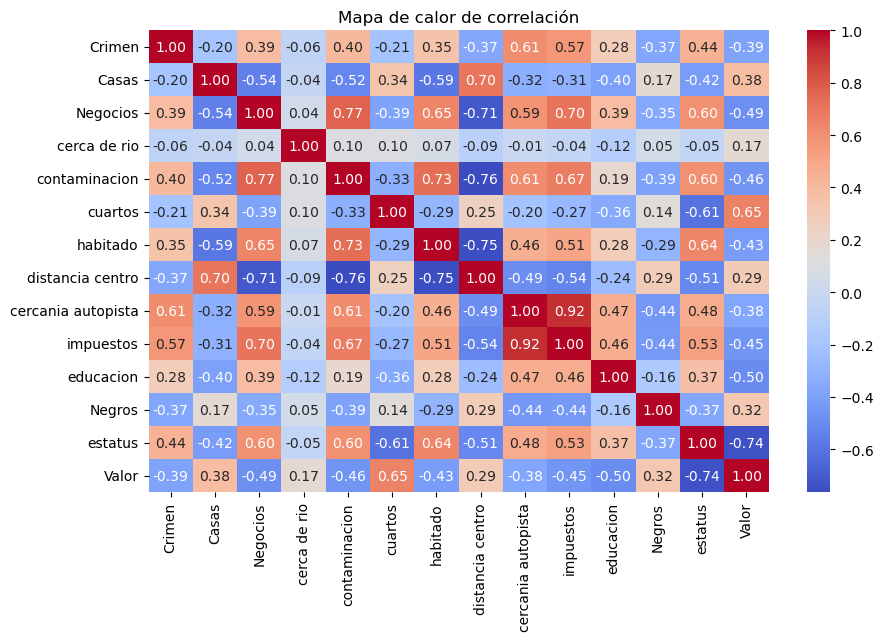

In [17]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de calor de correlación")
plt.show()

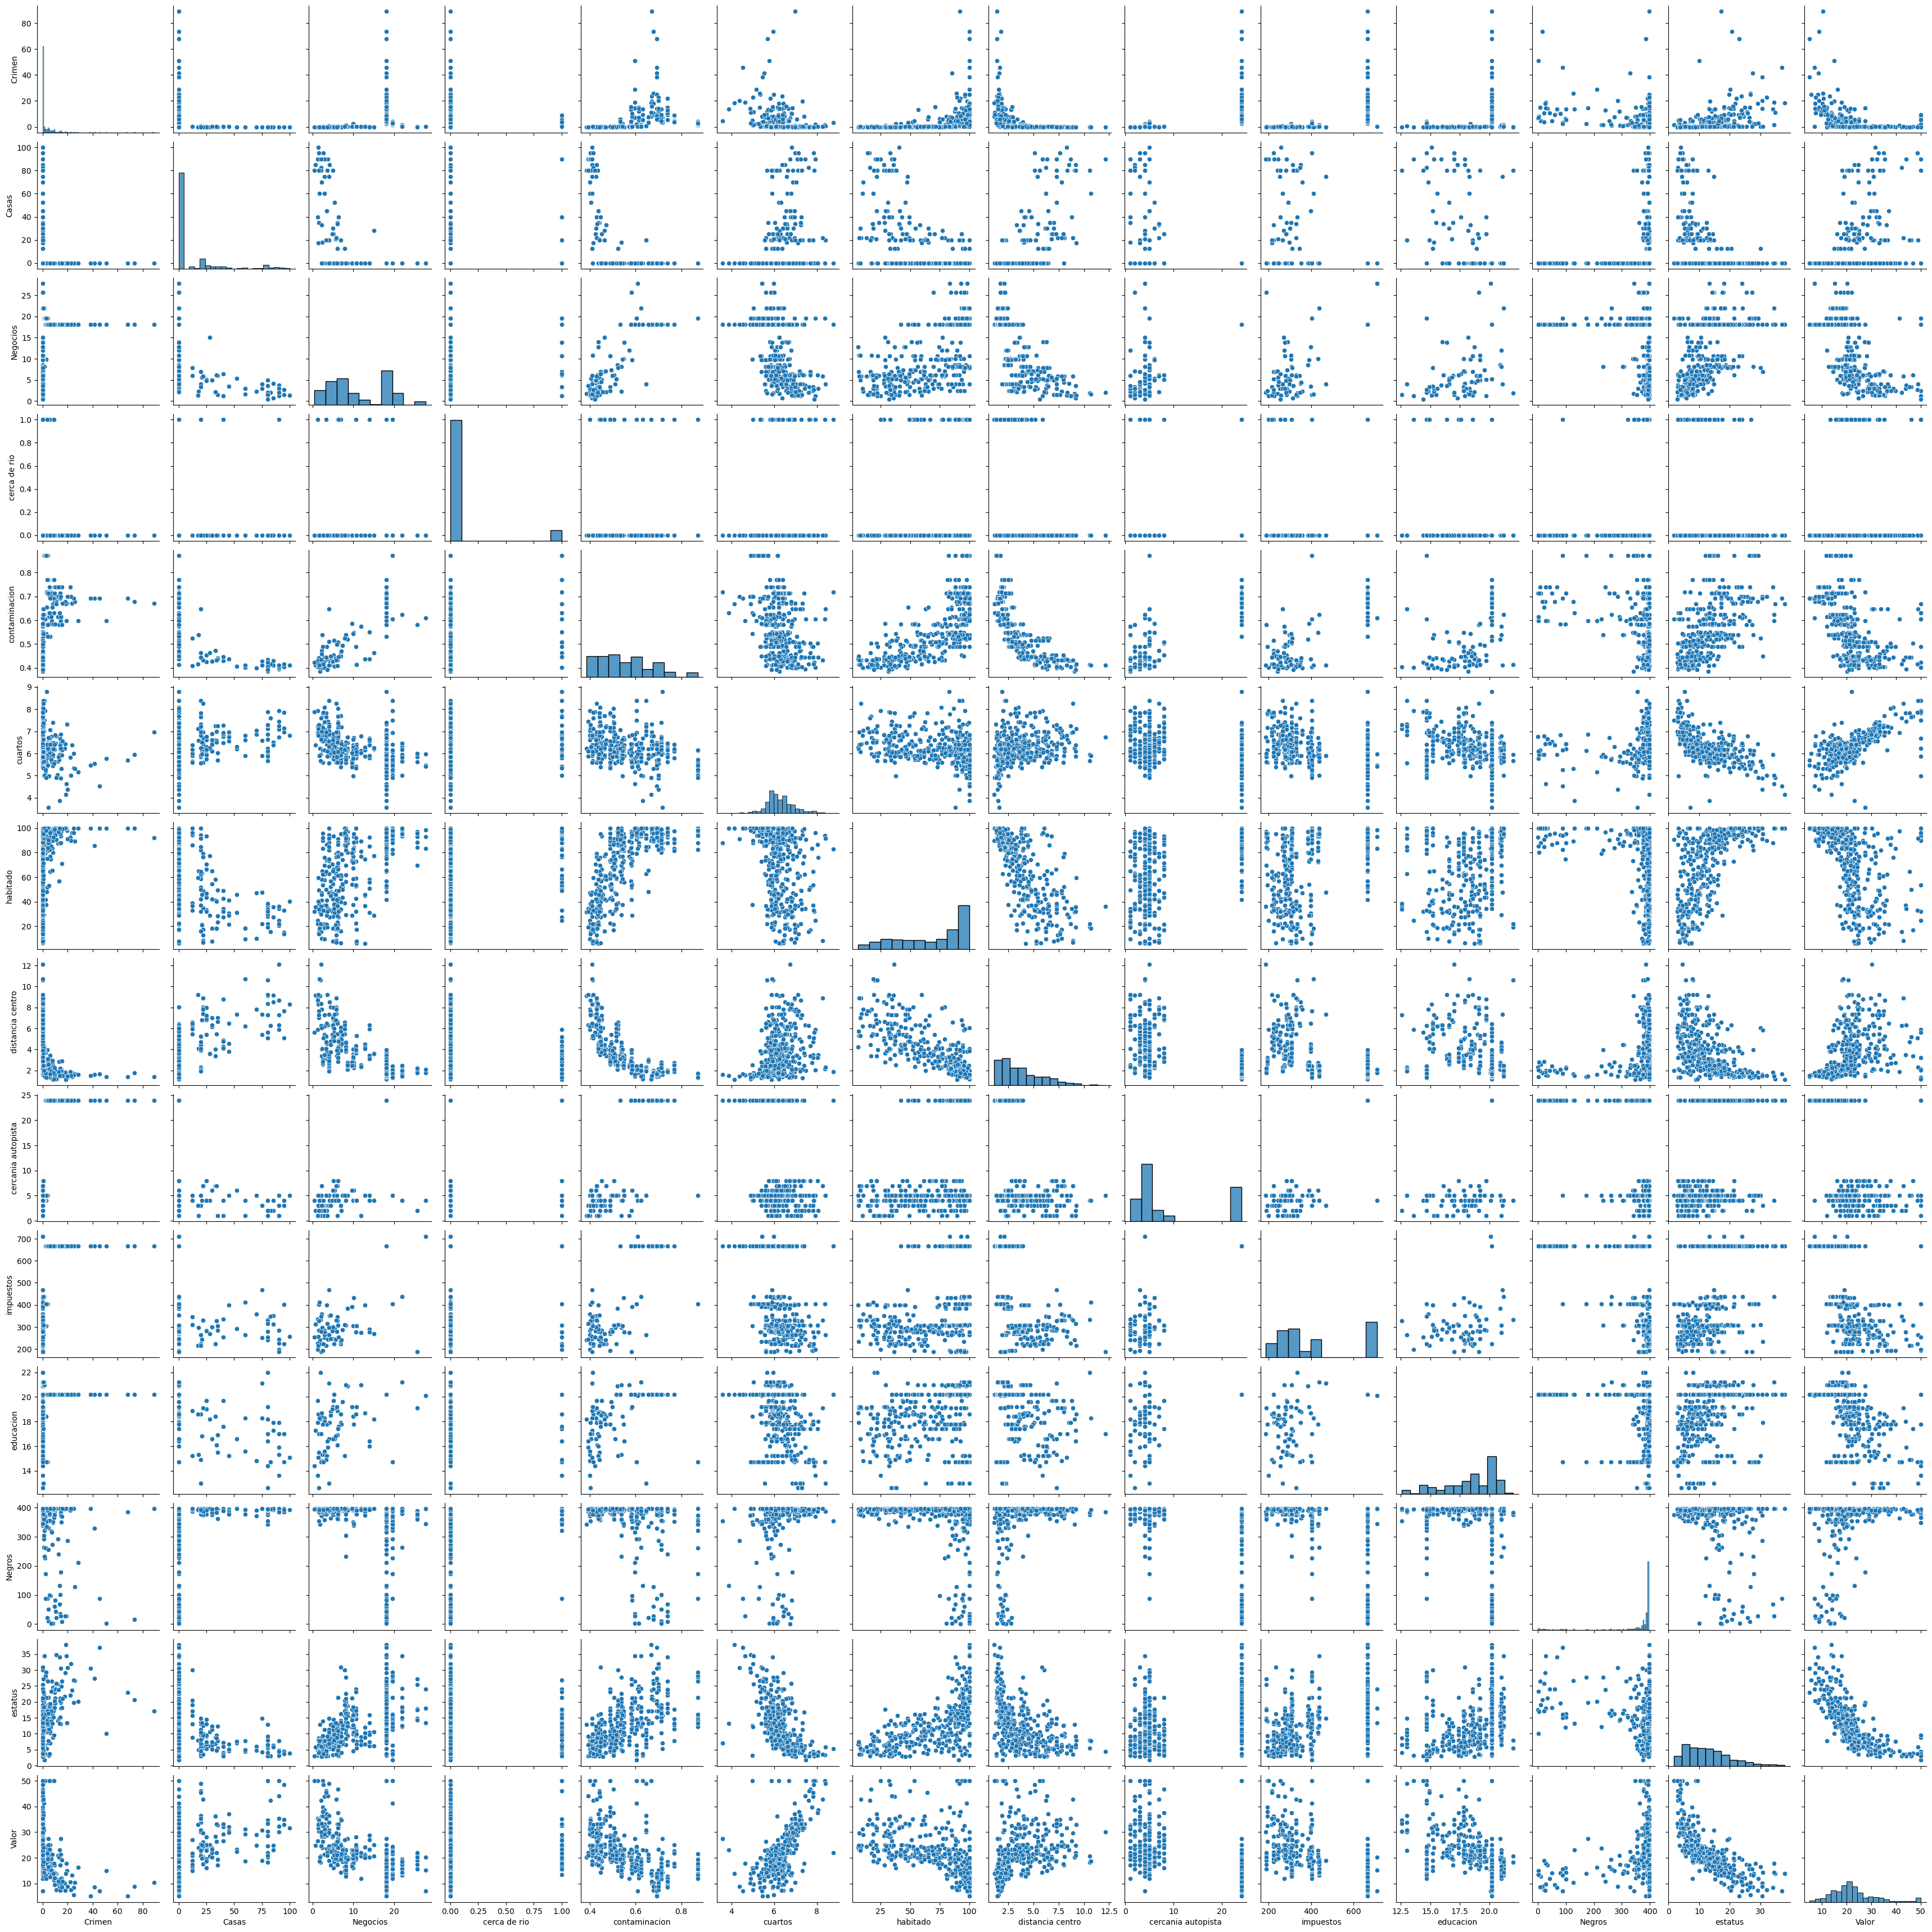

In [18]:
sns.pairplot(df)
plt.show()

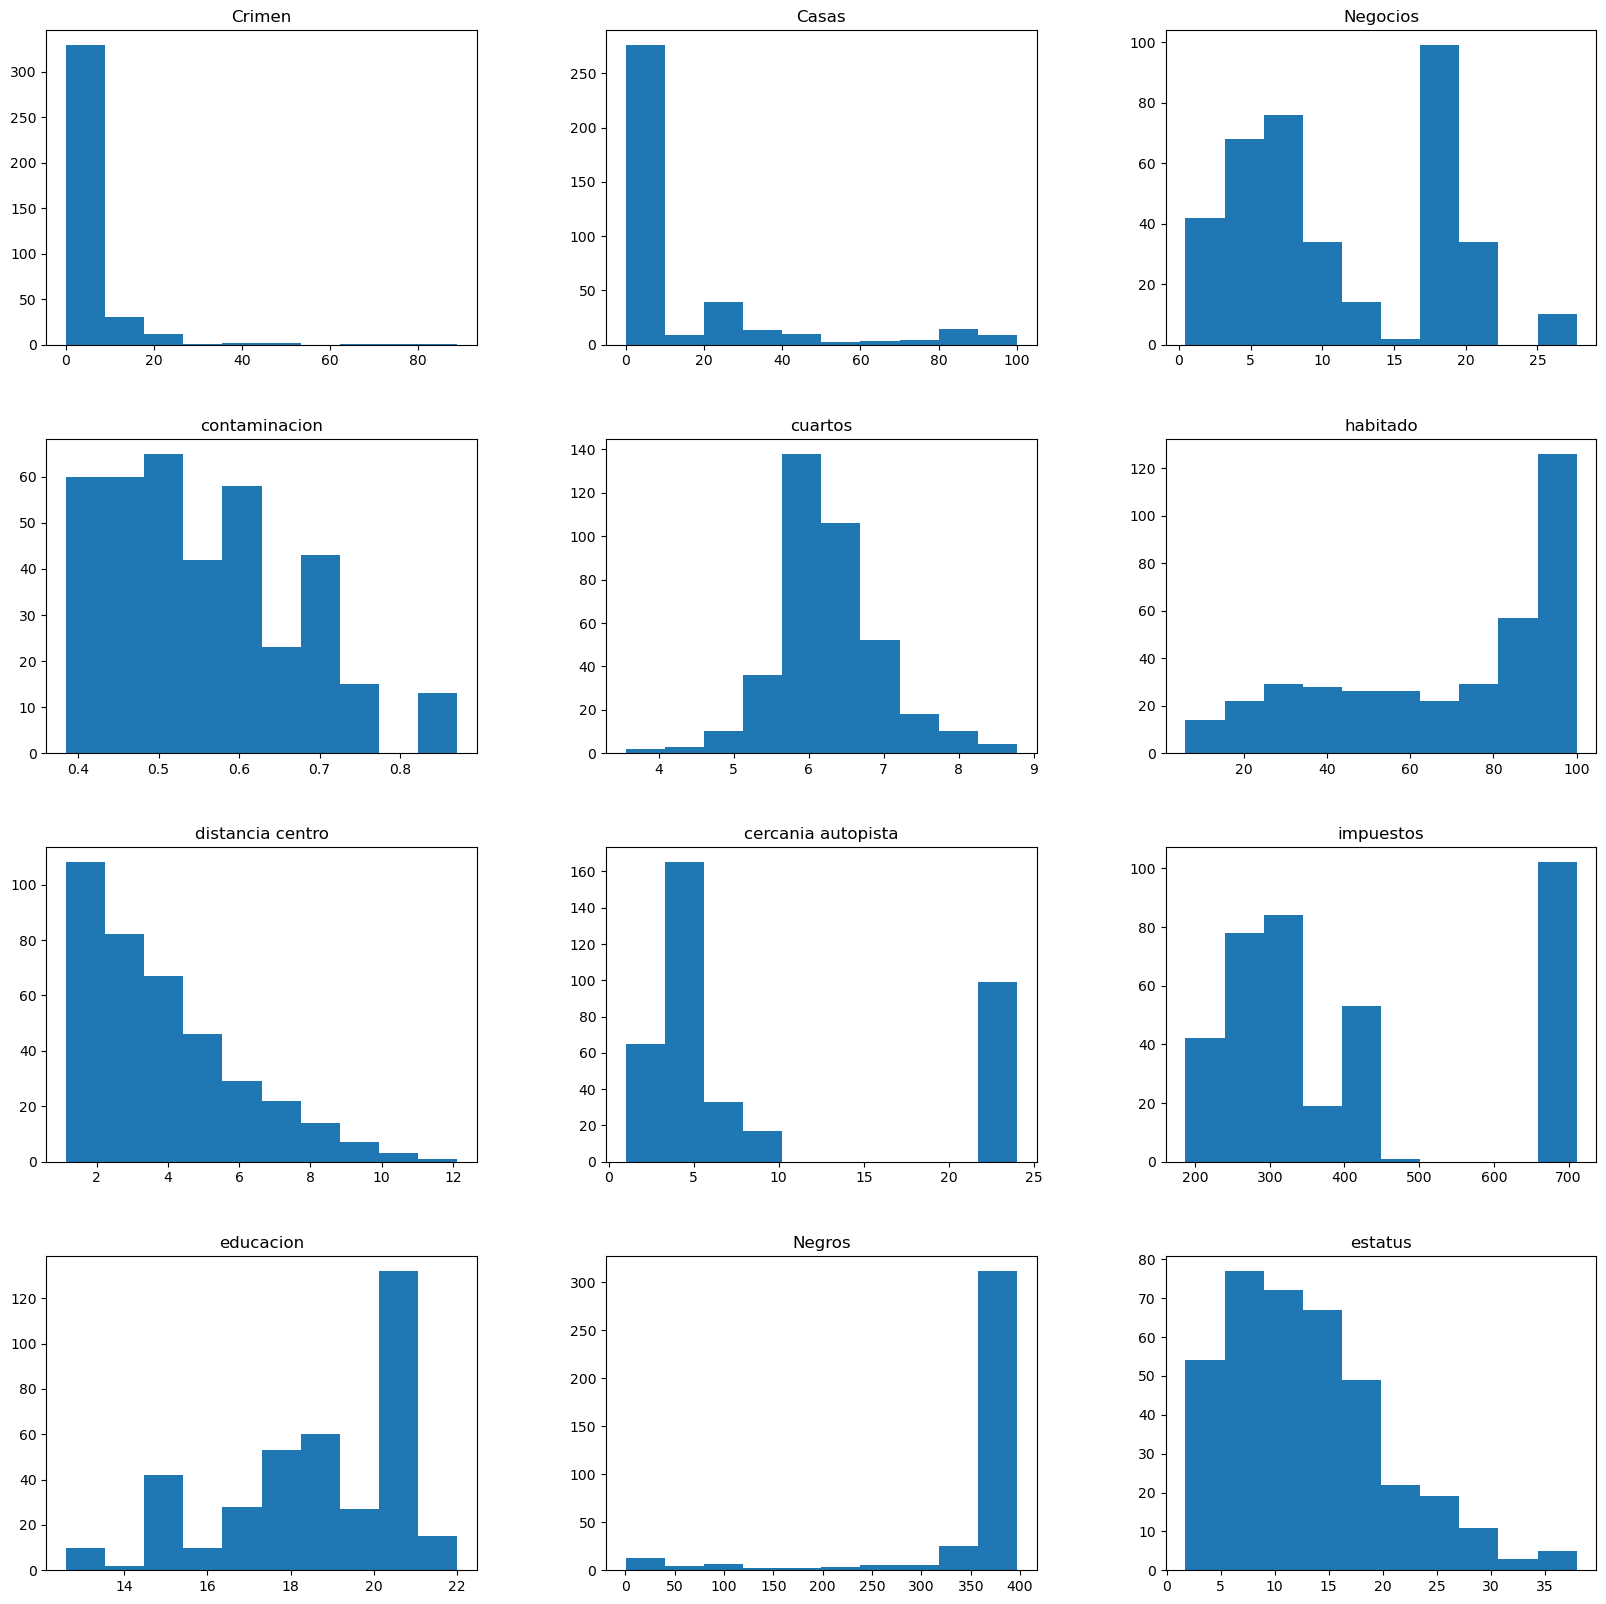

In [19]:
(df.drop(["cerca de rio","Valor"], axis=1)).hist(
    figsize=(20, 20),
    layout=(4, 3),
    grid=False
)

plt.show()

C:\Users\wilbe\AppData\Local\Temp\ipykernel_5348\2444987816.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y[X["cerca de rio"] == 1],hist=True ,label="YES", kde=True,color="blue")
C:\Users\wilbe\AppData\Local\Temp\ipykernel_5348\2444987816.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot

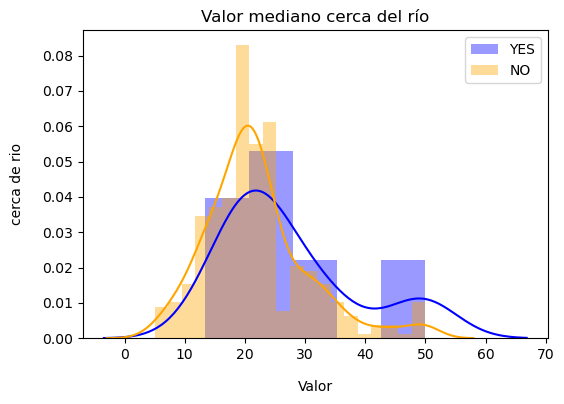

In [20]:
plt.figure(figsize=(6, 4))

sns.distplot(y[X["cerca de rio"] == 1],hist=True ,label="YES", kde=True,color="blue")
sns.distplot(y[X["cerca de rio"] == 0],hist=True, label="NO", kde=True,color="orange")

plt.xlabel("Valor", labelpad=13)
plt.ylabel("cerca de rio", labelpad=13)


plt.title("Valor mediano cerca del río")
plt.legend()
plt.show()

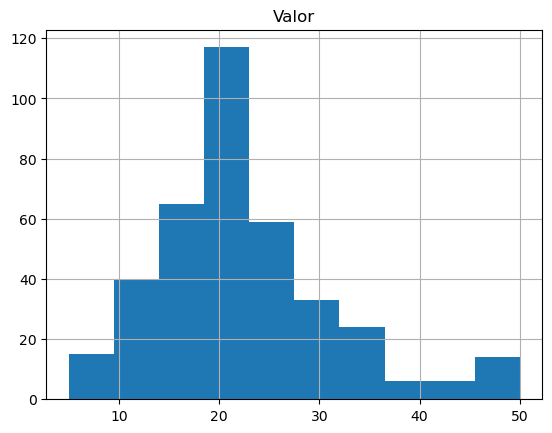

In [21]:
y.hist()
plt.show()

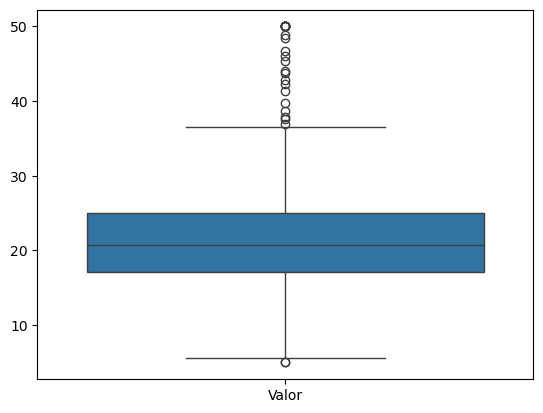

In [22]:
sns.boxplot(y)
plt.show()

## Quitar Valores extremos, agustar modelo

In [23]:
import statsmodels.api as sm

X_constant = sm.add_constant(X)
lin_reg = sm.OLS(y, X_constant).fit()
lin_reg.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Valor   R-squared:                       0.717
Model:                            OLS   Adj. R-squared:                  0.707
Method:                 Least Squares   F-statistic:                     71.07
Date:                Wed, 14 Jan 2026   Prob (F-statistic):           1.72e-91
Time:                        10:36:59   Log-Likelihood:                -1127.6
No. Observations:                 379   AIC:                             2283.
Df Residuals:                     365   BIC:                             2338.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 45.1925      6.005      7.526      0.000      33.385      57.000
Crimen                -0.1144      0.035     -3.276      0.001      -0.183      -0.046
Casas                  0.0571      0.017      3.332      0.001       0.023       0.091
Negocios               0.0383      0.071      0.540      0.590      -0.101       0.178
cerca de rio           2.4285      0.940      2.584      0.010       0.580       4.277
contaminacion        -21.2326      4.453     -4.768      0.000     -29.990     -12.476
cuartos                2.8772      0.497      5.786      0.000       1.899       3.855
habitado               0.0069      0.016      0.437      0.662      -0.024       0.038
distancia centro      -1.4716      0.240     -6.129      0.000      -1.944      -0.999
cercania autopista     0.3058      0.081      3.758      0.000       0.146       0.466
impuestos             -0.0107      0.005     -2.305      0.022      -0.020      -0.002
educacion             -0.9961      0.159     -6.284      0.000      -1.308      -0.684
Negros                 0.0063      0.003      1.950      0.052   -5.46e-05       0.013
estatus               -0.5574      0.059     -9.382      0.000      -0.674      -0.441
==============================================================================
Omnibus:                      149.481   Durbin-Watson:                   1.868
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              669.903
Skew:                           1.668   Prob(JB):                    3.41e-146
Kurtosis:                       8.593   Cond. No.                     1.51e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.51e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

si "Prob (F-statistic)" es menor a o,o5 quiere decir que si es significativo, "R-squared" mide la proporción de la variabilidad de la variable dependiente que es explicada por el modelo de regresión a partir de las variables independientes, si "P>|t|" es mayor a 0.05 indica que no son significativas en la regrecion y se deve ver tegnicas para que las variables sean significarivas

## Modelo de suposiciones

LINE

Residuales: Normal (miu =0,sigma^2 )

In [24]:
# residuos
resid_val = lin_reg.resid

# valores ajustados (predichos)
fitted_val = lin_reg.predict()

# media de los residuos
lin_reg.resid.mean()

np.float64(7.592870923030095e-15)

### Normalidad de residuales y Shapiro-wilk test

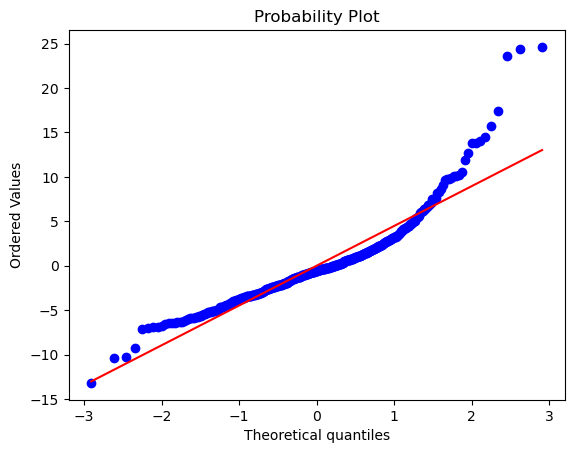

In [25]:
from scipy import stats

stats.probplot(resid_val, plot=plt)
plt.show()


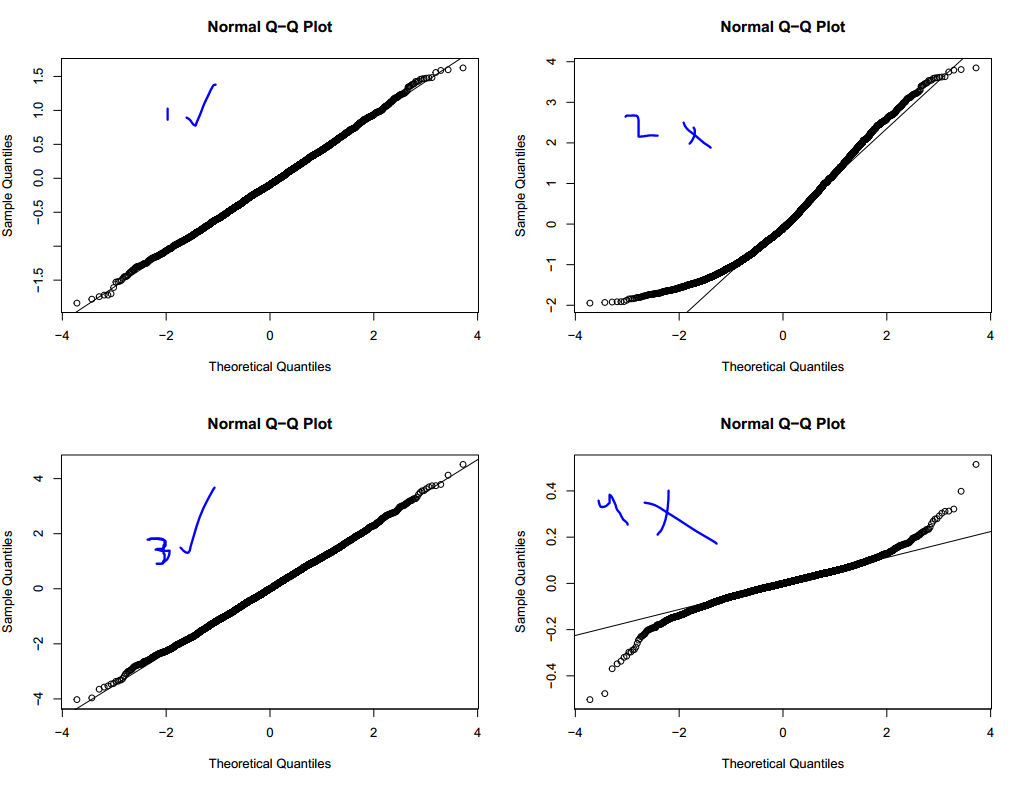!

In [26]:
stats.shapiro(lin_reg.resid)

ShapiroResult(statistic=np.float64(0.8845527815541799), pvalue=np.float64(2.858500930662003e-16))

ya que pvalue < 0.01, rechazo la hipotesis nula de que los valores se distribuyen normal.

### Linealidad en el modelo

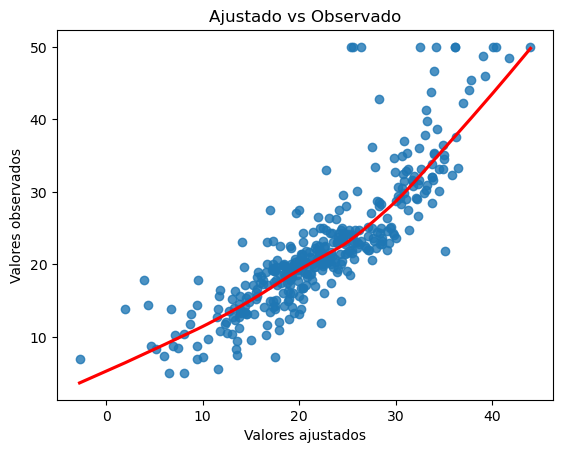

In [27]:
sns.regplot(
    x=fitted_val,
    y=y,
    lowess=True,
    line_kws={"color": "red"}
)

plt.xlabel("Valores ajustados")
plt.ylabel("Valores observados")
plt.title("Ajustado vs Observado")
plt.show()


### Homoscedasticidad: igualdad de varianzas

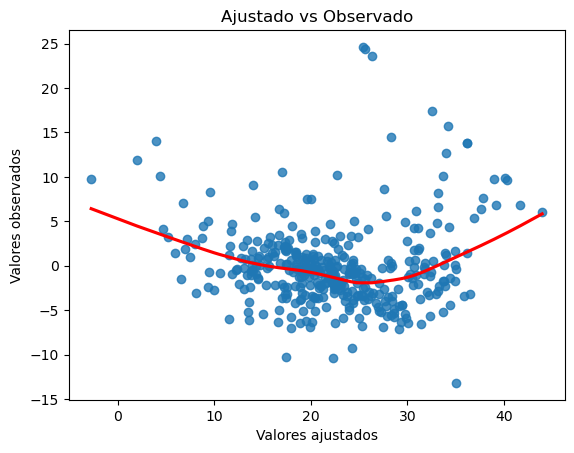

In [28]:
sns.regplot(
    x=fitted_val,
    y=resid_val,
    lowess=True,
    line_kws={"color": "red"}
)

plt.xlabel("Valores ajustados")
plt.ylabel("Valores observados")
plt.title("Ajustado vs Observado")
plt.show()

Como deberia ser:

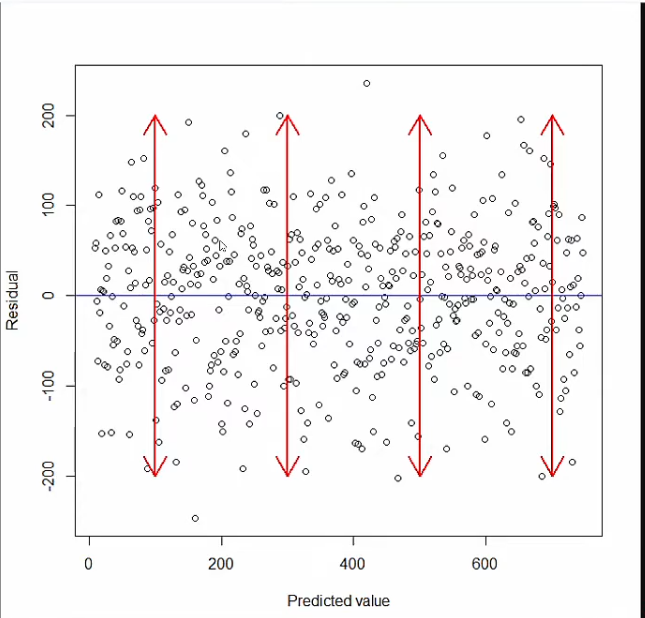

Cual se agusta mas?

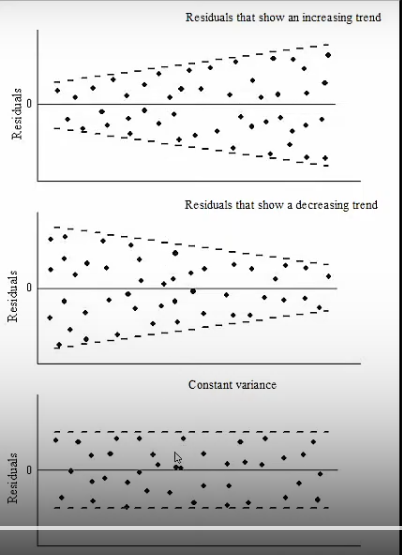

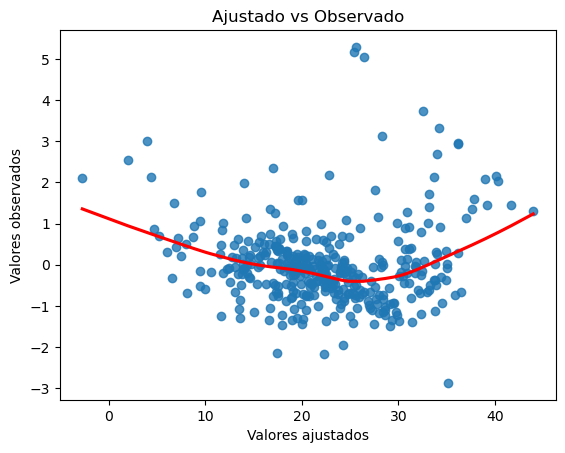

In [29]:
resid_stad = lin_reg.get_influence().resid_studentized_internal

sns.regplot(
    x=fitted_val,
    y=resid_stad,
    lowess=True,
    line_kws={"color": "red"}
)

plt.xlabel("Valores ajustados")
plt.ylabel("Valores observados")
plt.title("Ajustado vs Observado")
plt.show()

In [30]:
# Breusch-Pagan test para verificar igualdad de varianzas (homocedasticidad)
bp_test = sms.het_breuschpagan(resid_val, lin_reg.model.exog)

print(bp_test)
print("\nBreusch-Pagan Test: p-value =", bp_test[1])


(np.float64(51.45901922174513), np.float64(1.6719426732537469e-06), np.float64(4.411084441616728), np.float64(5.922839619577686e-07))

Breusch-Pagan Test: p-value = 1.6719426732537469e-06


Rechazo la ipotesis nula la cual es no tiene una varianza constante.

In [31]:
from statsmodels.stats.stattools import durbin_watson

print("Durbin-Watson value:")
print(durbin_watson(lin_reg.resid))


Durbin-Watson value:
1.8675628826067847


El Durbin–Watson (DW) sirve para detectar autocorrelación de los residuos, especialmente autocorrelación de primer orden en un modelo de regresión lineal.

Evalúa si los errores están correlacionados entre sí (algo que viola los supuestos del modelo).

| Valor DW | Interpretación                    |
| -------- | --------------------------------- |
| ≈ 2      | ✅ No hay autocorrelación          |
| < 2      | ⚠️ Autocorrelación positiva       |
| > 2      | ⚠️ Autocorrelación negativa       |
| ≈ 0      | ❌ Autocorrelación positiva fuerte |
| ≈ 4      | ❌ Autocorrelación negativa fuerte |


In [32]:
from scipy.stats import pearsonr

print("Correlación de Pearson:")
r, p_value = pearsonr(X["impuestos"], lin_reg.resid)

print("r =", r)
print("p-value =", p_value)


Correlación de Pearson:
r = 3.3688329903469594e-15
p-value = 0.9999999999999502


### Multicollinealidad

In [36]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = [
    variance_inflation_factor(X_constant.values, i)
    for i in range(X_constant.shape[1])
]

vif_df = pd.DataFrame(
    {"VIF": vif[1:]},   # excluimos la constante
    index=X.columns
)

vif_df.T

,Crimen,Casas,Negocios,cerca de rio,contaminacion,cuartos,habitado,distancia centro,cercania autopista,impuestos,educacion,Negros,estatus
VIF,1.73723,2.627307,3.856971,1.077297,4.458539,1.892447,3.235926,4.269367,8.179646,9.982152,1.866287,1.348138,2.99954


Si los varores son mayores a 5 se deve eliminar la variable ya que existe una multicollinealidad entre esa variable con respecto a otra. como en "cercania autopista".

## Eliminar Outliers

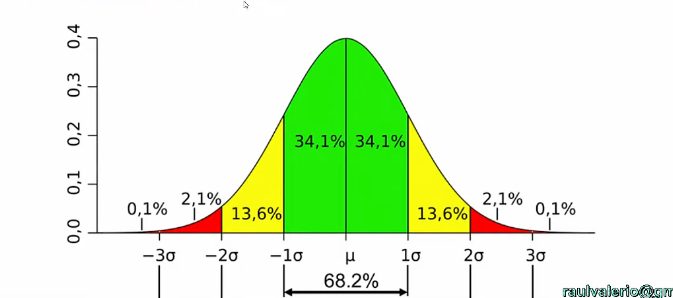

In [37]:
p3 = y.mean()+3*y.std()
p1 = y.mean()-3*y.std()

print(f"Valor maximo permitido: {p3}")
print(f"Valor minimo permitido: {p1}")

Valor maximo permitido: Valor    49.107383
dtype: float64
Valor minimo permitido: Valor   -4.418201
dtype: float64


### Rango IQR

In [54]:
# Asegurar que y sea Series
y = y.squeeze()

# IQR
q1 = y.quantile(0.25)
q3 = y.quantile(0.75)
iqr = q3 - q1

lower_limit = q1 - 1.5 * iqr
upper_limit = q3 + 1.5 * iqr

# Filtro correcto
mask = (y >= lower_limit) & (y <= upper_limit)

In [55]:
df_all = pd.concat([X, y], axis=1)

outliers = df_all[
    (df_all.iloc[:, -1] > upper_limit) |
    (df_all.iloc[:, -1] < lower_limit)
]

outliers

,Crimen,Casas,Negocios,cerca de rio,contaminacion,cuartos,habitado,distancia centro,cercania autopista,impuestos,educacion,Negros,estatus,Valor
180,0.06588,0.0,2.46,0.0,0.4880,7.765,83.3,2.7410,3.0,193.0,17.8,395.56,7.56,39.8
98,0.08187,0.0,2.89,0.0,0.4450,7.820,36.9,3.4952,2.0,276.0,18.0,393.53,3.57,43.8
161,1.46336,0.0,19.58,0.0,0.6050,7.489,90.8,1.9709,5.0,403.0,14.7,374.43,1.73,50.0
157,1.22358,0.0,19.58,0.0,0.6050,6.943,97.4,1.8773,5.0,403.0,14.7,363.43,4.59,41.3
186,0.05602,0.0,2.46,0.0,0.4880,7.831,53.6,3.1992,3.0,193.0,17.8,392.63,4.45,50.0
372,8.26725,0.0,18.10,1.0,0.6680,5.875,89.6,1.1296,24.0,666.0,20.2,347.88,8.88,50.0
256,0.01538,90.0,3.75,0.0,0.3940,7.454,34.2,6.3361,3.0,244.0,15.9,386.34,3.11,44.0
283,0.01501,90.0,1.21,1.0,0.4010,7.923,24.8,5.8850,1.0,198.0,13.6,395.52,3.16,50.0
163,1.51902,0.0,19.58,1.0,0.6050,8.375,93.9,2.1620,5.0,403.0,14.7,388.45,3.32,50.0
228,0.29819,0.0,6.20,0.0,0.5040,7.686,17.0,3.3751,8.0,307.0,17.4,377.51,3.92,46.7


In [56]:
X2 = X.loc[mask]
y2 = y.loc[mask]

In [57]:
print(type(y))
print(type(lower_limit))
print(type(upper_limit))


<class 'pandas.core.series.Series'>
<class 'numpy.float64'>
<class 'numpy.float64'>


In [58]:
print("Nuevo: ",X2.shape)
print("Original: ",X.shape)

Nuevo:  (352, 13)
Original:  (379, 13)


In [59]:
print("Nuevo: ",y2.shape)
print("Original: ",y.shape)

Nuevo:  (352,)
Original:  (379,)


### Variables con VIF

In [62]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X2 = X[mask]
y2 = y[mask]

# Agregar constante (ESTA LÍNEA ES CLAVE)
X2_constant = sm.add_constant(X2)

#  VIF
vif = [
    variance_inflation_factor(X2_constant.values, i)
    for i in range(X2_constant.shape[1])
]

vif_df = pd.DataFrame(
    {"VIF": vif[1:]},
    index=X2.columns
)

vif_df.T

,Crimen,Casas,Negocios,cerca de rio,contaminacion,cuartos,habitado,distancia centro,cercania autopista,impuestos,educacion,Negros,estatus
VIF,1.78103,2.69135,3.786373,1.077102,4.407433,1.764008,3.328152,4.443523,8.142432,9.769594,1.73586,1.38002,3.112939


In [63]:
pd.concat([X2[["impuestos","cercania autopista"]],y2],axis=1).corr()

,impuestos,cercania autopista,Valor
impuestos,1.000000,0.918772,-0.575629
cercania autopista,0.918772,1.000000,-0.491530
Valor,-0.575629,-0.491530,1.000000


Eliminar la correlacion mar cercana a 0 ya que la mas lejana explica mejor el valor , pero valotizar caul tiene mas relaciones en cojunto con las otra variables.

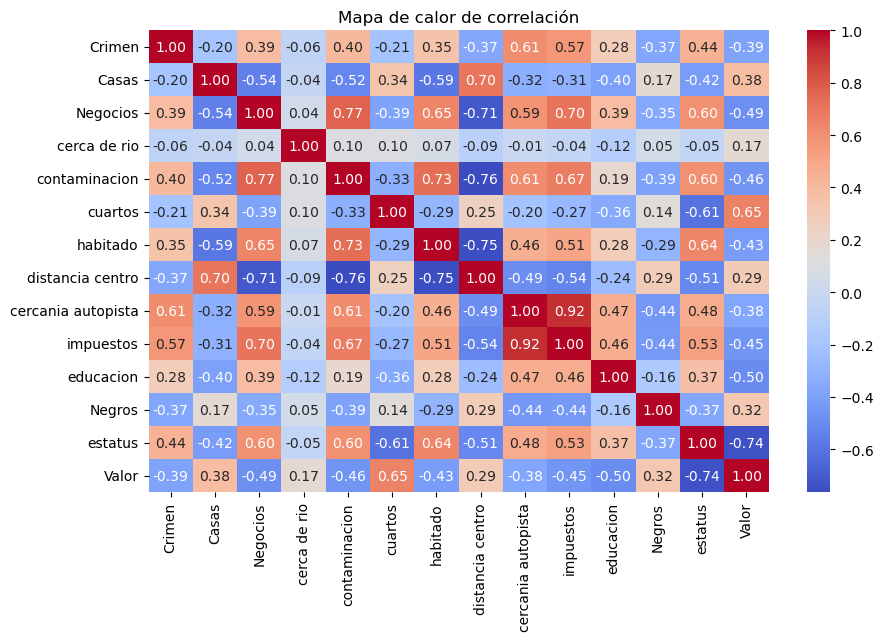

In [64]:
plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Mapa de calor de correlación")
plt.show()

Eliminaremos "impuestos"

In [65]:
X2 = X2.drop("impuestos",axis=1)
X2.head(2)

,Crimen,Casas,Negocios,cerca de rio,contaminacion,cuartos,habitado,distancia centro,cercania autopista,educacion,Negros,estatus
502,0.04527,0.0,11.93,0.0,0.573,6.120,76.7,2.2875,1.0,21.0,396.9,9.08
172,0.13914,0.0,4.05,0.0,0.510,5.572,88.5,2.5961,5.0,16.6,396.9,14.69


## Nuevo modelo lineal

In [66]:
X_constant = sm.add_constant(X2)
lin_reg_2 = sm.OLS(y2,X_constant).fit()
lin_reg_2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Valor   R-squared:                       0.763
Model:                            OLS   Adj. R-squared:                  0.754
Method:                 Least Squares   F-statistic:                     90.80
Date:                Wed, 14 Jan 2026   Prob (F-statistic):           4.28e-98
Time:                        11:03:21   Log-Likelihood:                -901.27
No. Observations:                 352   AIC:                             1829.
Df Residuals:                     339   BIC:                             1879.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 42.9822      4.175     10.296      0.000      34.771      51.194
Crimen                -0.1033      0.026     -4.034      0.000      -0.154      -0.053
Casas                  0.0311      0.012      2.608      0.010       0.008       0.055
Negocios              -0.1069      0.045     -2.359      0.019      -0.196      -0.018
cerca de rio           1.5411      0.668      2.306      0.022       0.227       2.855
contaminacion        -15.5863      2.994     -5.206      0.000     -21.476      -9.697
cuartos                1.6676      0.382      4.365      0.000       0.916       2.419
habitado              -0.0206      0.011     -1.854      0.065      -0.042       0.001
distancia centro      -1.0091      0.167     -6.042      0.000      -1.338      -0.681
cercania autopista     0.0811      0.032      2.497      0.013       0.017       0.145
educacion             -0.8186      0.107     -7.620      0.000      -1.030      -0.607
Negros                 0.0055      0.002      2.538      0.012       0.001       0.010
estatus               -0.3613      0.043     -8.461      0.000      -0.445      -0.277
==============================================================================
Omnibus:                       31.108   Durbin-Watson:                   2.049
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               42.800
Skew:                           0.634   Prob(JB):                     5.08e-10
Kurtosis:                       4.144   Cond. No.                     1.02e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.02e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Supociciones

In [67]:
resid_val_2 = lin_reg_2.resid

# valores ajustados (predichos)
fitted_val_2 = lin_reg_2.predict()

# media de los residuos
lin_reg_2.resid.mean()

np.float64(-2.37537262586846e-14)

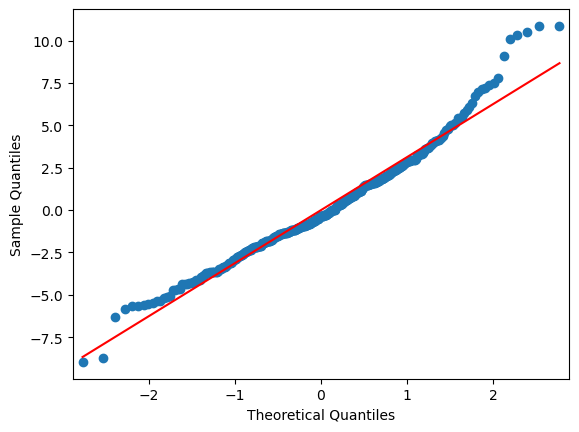

In [68]:
sm.qqplot(resid_val_2,line="s")

In [69]:
stats.shapiro(lin_reg.resid)

ShapiroResult(statistic=np.float64(0.8845527815541799), pvalue=np.float64(2.858500930662003e-16))

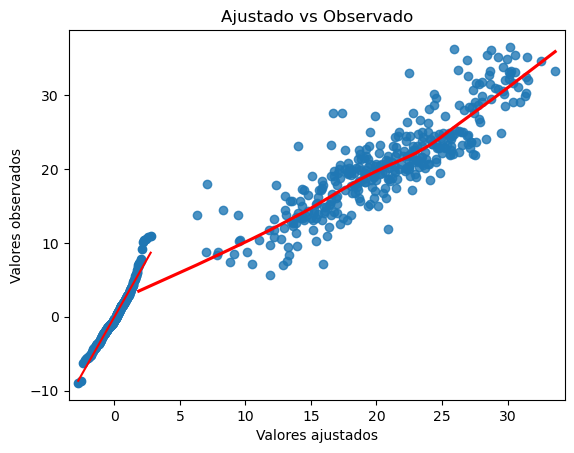

In [70]:
sns.regplot(
    x=fitted_val_2,
    y=y2,
    lowess=True,
    line_kws={"color": "red"}
)

plt.xlabel("Valores ajustados")
plt.ylabel("Valores observados")
plt.title("Ajustado vs Observado")
plt.show()


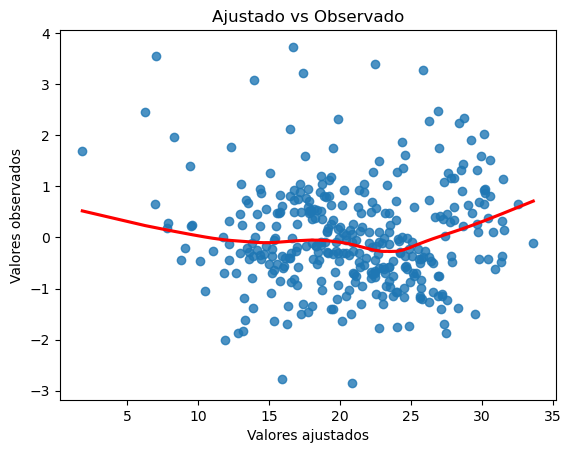

In [71]:
resid_stad_2 = lin_reg_2.get_influence().resid_studentized_internal

sns.regplot(
    x=fitted_val_2,
    y=resid_stad_2,
    lowess=True,
    line_kws={"color": "red"}
)

plt.xlabel("Valores ajustados")
plt.ylabel("Valores observados")
plt.title("Ajustado vs Observado")
plt.show()

In [72]:
# Breusch-Pagan test para verificar igualdad de varianzas (homocedasticidad)
bp_test_2 = sms.het_breuschpagan(resid_val_2, lin_reg_2.model.exog)

print(bp_test_2)
print("\nBreusch-Pagan Test: p-value =", bp_test_2[1])


(np.float64(17.9473503569173), np.float64(0.1172985220553838), np.float64(1.5177626883804969), np.float64(0.11567920926823104))

Breusch-Pagan Test: p-value = 0.1172985220553838


No se rechaza la hipotesis nula p-value > 0.5, por tanto cumple la homoelastisidad apropiada, mejorando el modelo.

## Apalancamiento

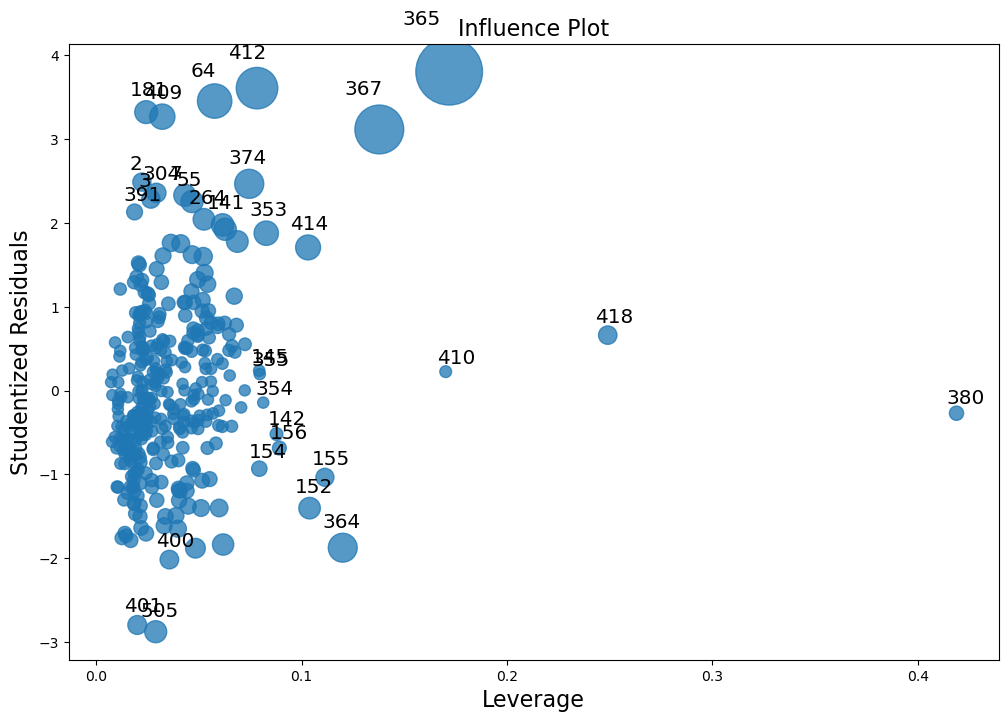

In [73]:
# influencia de puntos: cook distance

fig, ax = plt.subplots(figsize=(12, 8))

sm.graphics.influence_plot(
    lin_reg_2,
    alpha=0.05,
    ax=ax,
    criterion="cooks"
)

plt.show()


* Valores limite apalancamiento: 2*p , p numero de coeficiente,n numeros de obcervaciones.
* Valores limite cook: 4, regla de dedo.

In [74]:
X2.loc[[365,367,412,374]]

,Crimen,Casas,Negocios,cerca de rio,contaminacion,cuartos,habitado,distancia centro,cercania autopista,educacion,Negros,estatus
365,4.55587,0.0,18.1,0.0,0.718,3.561,87.9,1.6132,24.0,20.2,354.70,7.12
367,13.52220,0.0,18.1,0.0,0.631,3.863,100.0,1.5106,24.0,20.2,131.42,13.33
412,18.81100,0.0,18.1,0.0,0.597,4.628,100.0,1.5539,24.0,20.2,28.79,34.37
374,18.49820,0.0,18.1,0.0,0.668,4.138,100.0,1.1370,24.0,20.2,396.90,37.97


In [75]:
y2.loc[[365,367,412,374]]

365    27.5
367    23.1
412    17.9
374    13.8
Name: Valor, dtype: float64

In [76]:
influence = lin_reg_2.get_influence()

cooks = influence.cooks_distance

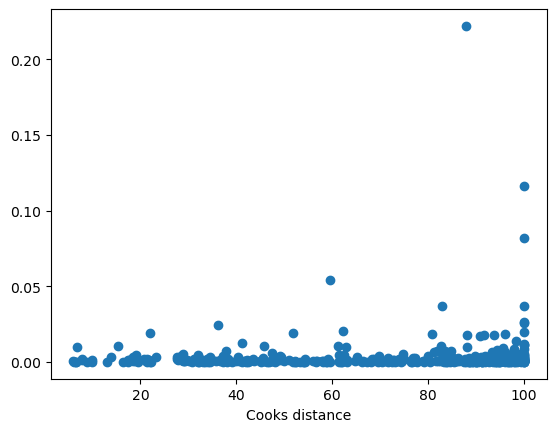

In [77]:
plt.scatter(X2["habitado"],cooks[0])
plt.xlabel("X")
plt.xlabel("Cooks distance")
plt.show()

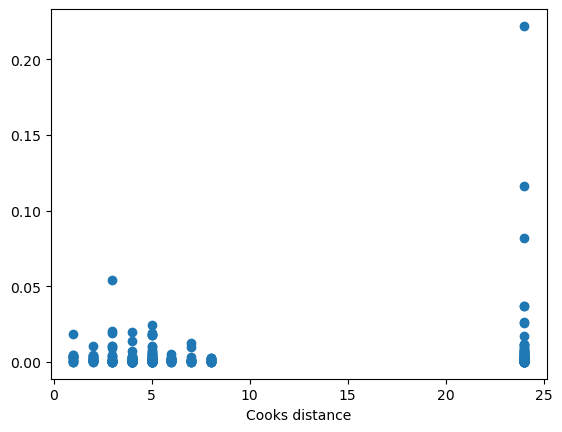

In [78]:
plt.scatter(X2["cercania autopista"],cooks[0])
plt.xlabel("X")
plt.xlabel("Cooks distance")
plt.show()

In [79]:
k = cooks[0] > 0.05

In [80]:
X2[k]

,Crimen,Casas,Negocios,cerca de rio,contaminacion,cuartos,habitado,distancia centro,cercania autopista,educacion,Negros,estatus
365,4.55587,0.0,18.10,0.0,0.7180,3.561,87.9,1.6132,24.0,20.2,354.70,7.12
412,18.81100,0.0,18.10,0.0,0.5970,4.628,100.0,1.5539,24.0,20.2,28.79,34.37
367,13.52220,0.0,18.10,0.0,0.6310,3.863,100.0,1.5106,24.0,20.2,131.42,13.33
64,0.01951,17.5,1.38,0.0,0.4161,7.104,59.5,9.2229,3.0,18.6,393.24,8.05


In [81]:
y2[k]

365    27.5
412    17.9
367    23.1
64     33.0
Name: Valor, dtype: float64

In [82]:
# 3 dataset

X3 = X2.loc[ k!=1,:] 
y3 = y2.loc[ k!=1 ]

X3.shape

(348, 12)

## Modelo lineal ajustado

In [83]:
X_constant =sm.add_constant(X3)
lin_reg_3 = sm.OLS(y3,X_constant).fit()
lin_reg_3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Valor   R-squared:                       0.796
Model:                            OLS   Adj. R-squared:                  0.789
Method:                 Least Squares   F-statistic:                     108.9
Date:                Wed, 14 Jan 2026   Prob (F-statistic):          9.04e-108
Time:                        11:04:17   Log-Likelihood:                -864.22
No. Observations:                 348   AIC:                             1754.
Df Residuals:                     335   BIC:                             1805.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 32.4389      4.303      7.539      0.000      23.975      40.903
Crimen                -0.0957      0.024     -4.021      0.000      -0.142      -0.049
Casas                  0.0259      0.011      2.306      0.022       0.004       0.048
Negocios              -0.0982      0.042     -2.340      0.020      -0.181      -0.016
cerca de rio           1.4596      0.619      2.358      0.019       0.242       2.677
contaminacion        -13.3328      2.817     -4.734      0.000     -18.873      -7.793
cuartos                2.8891      0.415      6.961      0.000       2.073       3.706
habitado              -0.0351      0.011     -3.333      0.001      -0.056      -0.014
distancia centro      -1.0022      0.159     -6.307      0.000      -1.315      -0.690
cercania autopista     0.0377      0.031      1.220      0.223      -0.023       0.099
educacion             -0.7767      0.100     -7.790      0.000      -0.973      -0.581
Negros                 0.0082      0.002      3.971      0.000       0.004       0.012
estatus               -0.2729      0.044     -6.272      0.000      -0.358      -0.187
==============================================================================
Omnibus:                       12.509   Durbin-Watson:                   2.114
Prob(Omnibus):                  0.002   Jarque-Bera (JB):               16.282
Skew:                           0.314   Prob(JB):                     0.000291
Kurtosis:                       3.853   Cond. No.                     1.11e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.11e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

In [84]:
vif = [
    variance_inflation_factor(X_constant.values, i)
    for i in range(X_constant.shape[1])
]

vif_df = pd.DataFrame(
    {"VIF": vif[1:]},   # excluimos la constante
    index=X3.columns
)

vif_df.T

,Crimen,Casas,Negocios,cerca de rio,contaminacion,cuartos,habitado,distancia centro,cercania autopista,educacion,Negros,estatus
VIF,1.768827,2.541613,3.217636,1.056042,4.455494,2.116839,3.443869,4.539599,2.873556,1.706112,1.379091,3.657491


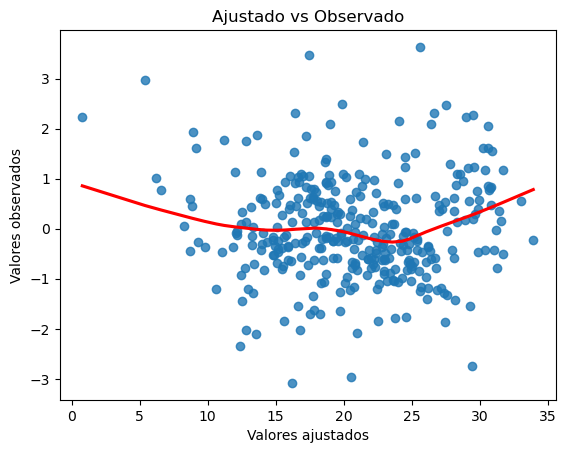

In [86]:
resid_val_3= lin_reg_3.resid
fitted_val_3 = lin_reg_3.predict()

resid_stad_3 = lin_reg_3.get_influence().resid_studentized_internal

sns.regplot(
    x=fitted_val_3,
    y=resid_stad_3,
    lowess=True,
    line_kws={"color": "red"}
)

plt.xlabel("Valores ajustados")
plt.ylabel("Valores observados")
plt.title("Ajustado vs Observado")
plt.show()

## Rendimiento de modelos

In [87]:
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error

# =========================
# MODELO 1 (datos originales)
# =========================
X1_const = sm.add_constant(X)
lin_reg_1 = sm.OLS(y, X1_const).fit()
pred_1 = lin_reg_1.predict(X1_const)

# =========================
# MODELO 2 (sin outliers)
# =========================
X2_const = sm.add_constant(X2)
lin_reg_2 = sm.OLS(y2, X2_const).fit()
pred_2 = lin_reg_2.predict(X2_const)

# =========================
# MODELO 3 (variables ajustadas)
# =========================
X3_const = sm.add_constant(X3)
lin_reg_3 = sm.OLS(y3, X3_const).fit()
pred_3 = lin_reg_3.predict(X3_const)

# =========================
# MÉTRICAS
# =========================
print("Coeficiente de determinación (R²)")
print("Modelo 1:", r2_score(y, pred_1))
print("Modelo 2:", r2_score(y2, pred_2))
print("Modelo 3:", r2_score(y3, pred_3))

print("\nError Cuadrático Medio (MSE)")
print("Modelo 1:", mean_squared_error(y, pred_1))
print("Modelo 2:", mean_squared_error(y2, pred_2))
print("Modelo 3:", mean_squared_error(y3, pred_3))


Coeficiente de determinación (R²)
Modelo 1: 0.7168057552393374
Modelo 2: 0.7627068207872779
Modelo 3: 0.7959831904020425

Error Cuadrático Medio (MSE)
Modelo 1: 22.477983821877896
Modelo 2: 9.806088845651578
Modelo 3: 8.405464303999922


Si R^2 esta cercano a 100% o MSE es muy cercano a 0 o hay mucha diferencia entre los modelos ,quiere decir que existe un sobre ajuste , esto afecta de manera negativa ya que no sera precisa con la mayoria de datos.

In [88]:
# =========================
# MODELO 1 (completo)
# =========================
Xnew_1 = sm.add_constant(X_test)
pred_test_1 = lin_reg_1.predict(Xnew_1)

# =========================
# MODELO 2 (sin TAX)
# =========================
Xnew_2 = sm.add_constant(X_test.drop(["impuestos"], axis=1))
pred_test_2 = lin_reg_2.predict(Xnew_2)

# =========================
# MODELO 3 (sin TAX)
# =========================
Xnew_3 = sm.add_constant(X_test.drop(["impuestos"], axis=1))
pred_test_3 = lin_reg_3.predict(Xnew_3)

# =========================
# MÉTRICAS
# =========================
print("Coeficiente de determinación (R²)")
print("R² test modelo 1:", r2_score(y_test, pred_test_1))
print("R² test modelo 2:", r2_score(y_test, pred_test_2))
print("R² test modelo 3:", r2_score(y_test, pred_test_3))

print("\nMean Squared Error (MSE)")
print("MSE test modelo 1:", mean_squared_error(y_test, pred_test_1))
print("MSE test modelo 2:", mean_squared_error(y_test, pred_test_2))
print("MSE test modelo 3:", mean_squared_error(y_test, pred_test_3))


Coeficiente de determinación (R²)
R² test modelo 1: 0.7789410172622871
R² test modelo 2: 0.6493321352610418
R² test modelo 3: 0.6846532054649843

Mean Squared Error (MSE)
MSE test modelo 1: 21.89776539604936
MSE test modelo 2: 34.73662340651519
MSE test modelo 3: 31.23777210771488


Eliminando otra variable para comparativa

In [89]:
X4 = X3.drop("cercania autopista",axis=1)
X_constant = sm.add_constant(X4)
lin_reg_4 = sm.OLS(y3,X_constant).fit()
lin_reg_4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Valor   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.788
Method:                 Least Squares   F-statistic:                     118.5
Date:                Wed, 14 Jan 2026   Prob (F-statistic):          1.69e-108
Time:                        11:05:21   Log-Likelihood:                -864.99
No. Observations:                 348   AIC:                             1754.
Df Residuals:                     336   BIC:                             1800.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const               30.2551      3.916      7.726      0.000      22.552      37.958
Crimen              -0.0837      0.022     -3.859      0.000      -0.126      -0.041
Casas                0.0264      0.011      2.344      0.020       0.004       0.049
Negocios            -0.0939      0.042     -2.244      0.025      -0.176      -0.012
cerca de rio         1.4397      0.619      2.325      0.021       0.221       2.658
contaminacion      -12.1053      2.633     -4.598      0.000     -17.284      -6.927
cuartos              3.0417      0.396      7.680      0.000       2.263       3.821
habitado            -0.0370      0.010     -3.548      0.000      -0.057      -0.016
distancia centro    -0.9963      0.159     -6.268      0.000      -1.309      -0.684
educacion           -0.7285      0.092     -7.951      0.000      -0.909      -0.548
Negros               0.0079      0.002      3.865      0.000       0.004       0.012
estatus             -0.2639      0.043     -6.150      0.000      -0.348      -0.179
==============================================================================
Omnibus:                       13.901   Durbin-Watson:                   2.124
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               18.322
Skew:                           0.340   Prob(JB):                     0.000105
Kurtosis:                       3.895   Cond. No.                     9.98e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.98e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Tenemos el mismo desempeño al quitar incluso una variable mas, es un exito el modelo 3.